In [3]:
!pip install yfinance mplfinance opencv-python

In [4]:
import os

base_dir = "/content/stock-pattern-cnn"

folders = [
    "data/raw",
    "data/images/train",
    "data/images/val",
    "data/images/test"
]

patterns = [
    "head_and_shoulders",
    "double_top",
    "double_bottom",
    "ascending_triangle",
    "descending_triangle",
    "no_pattern"
]

In [5]:
for folder in folders:
    for pattern in patterns:
        os.makedirs(f"{base_dir}/{folder}/{pattern}", exist_ok=True)

In [6]:
import yfinance as yf

In [7]:
stocks = {
    "RELIANCE.NS","HDFCBANK.NS","ICICIBANK.NS","ITC.NS","INFY.NS","TCS.NS","SBIN.NS","MARUTI.NS","HINDUNILVR.NS"
}

In [8]:
for stock in stocks:
  df = yf.download(stock,start='2019-01-01',end='2024-01-01')
  df.to_csv(f"{base_dir}/data/raw/{stock}.csv")

/tmp/ipython-input-1971813196.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock,start='2019-01-01',end='2024-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1971813196.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock,start='2019-01-01',end='2024-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1971813196.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock,start='2019-01-01',end='2024-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1971813196.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock,start='2019-01-01',end='2024-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1

In [9]:
import pandas as pd
import mplfinance as mpf

WINDOW = 60

In [10]:
save_dir = os.path.join(base_dir, "data/images/train/no_pattern")
os.makedirs(save_dir, exist_ok=True)

In [11]:
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [12]:
STEP = 3

def generate_charts(csv_path, save_dir, stock_name):
    df = pd.read_csv(csv_path)

    df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], errors="coerce")
    df.set_index(df.columns[0], inplace=True)

    df = df[["Open", "High", "Low", "Close"]]

    df = df.apply(pd.to_numeric, errors='coerce')

    df = df.dropna(subset=["Open", "High", "Low", "Close"])

    for i in range(0,len(df) - WINDOW,STEP):
        window_df = df.iloc[i:i+WINDOW]
        filename = f"{stock_name}_{i}.png"

        mpf.plot(
            window_df,
            type='candle',
            style='charles',
            savefig=dict(fname=os.path.join(save_dir, filename), dpi=100, pad_inches=0.1)
        )

In [13]:
for stock in stocks:
    csv_file = os.path.join(base_dir, f"data/raw/{stock}.csv")
    generate_charts(csv_file, save_dir, stock)

/tmp/ipython-input-1685127430.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], errors="coerce")
/tmp/ipython-input-1685127430.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], errors="coerce")
/tmp/ipython-input-1685127430.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], errors="coerce")
/tmp/ipython-input-1685127430.py:6: UserWarning: Could not infer format, so each element will be parsed individually, fal

In [14]:
num_images = len([f for f in os.listdir(save_dir) if os.path.isfile(os.path.join(save_dir, f))])
print(f"Number of images in no_pattern: {num_images}")

Number of images in no_pattern: 6468


In [15]:
import numpy as np

def find_local_extremas(series,order = 3):
    peaks = []
    troughs = []

    for i in range(order , len(series) - order):
      window = series[i-order:i+order+1]

      if series[i] == max(window):
        peaks.append(i)

      if series[i] == min(window):
        troughs.append(i)

    return peaks,troughs

In [16]:
def is_double_top(df,tolerance=0.02):
  close = pd.to_numeric(df["Close"], errors="coerce").values
  peaks,troughs = find_local_extremas(close)

  if len(peaks)<2:
    return False

  for i in range(len(peaks) -1):
    p1,p2 = peaks[i] , peaks[i+1]
    price1 , price2 = close[p1],close[p2]

    if abs(price1-price2)/price1 < tolerance:
      mid_min = close[p1:p2].min()
      if mid_min < min(price1,price2) * 0.97:
        return True

  return False

In [17]:
def is_double_bottom(df,tolerance=0.02):
  close = pd.to_numeric(df["Close"], errors="coerce").values
  peaks,troughs = find_local_extremas(close)

  if len(troughs) < 2:
    return False

  for i in range(len(troughs) - 1):
    t1,t2 = troughs[i],troughs[i+1]
    price1,price2 = close[t1],close[t2]

    if abs(price1 - price2)/price1 < tolerance:
      mid_max = close[t1:t2].max()
      if mid_max > min(price1,price2)*1.03:
        return True

  return False

In [18]:
def is_head_and_shoulders(df,tolerance = 0.02):
  close = pd.to_numeric(df["Close"], errors="coerce").values
  peaks,troughs = find_local_extremas(close)

  if len(peaks) < 3:
    return False

  for i in range(len(peaks) - 2):
    p1,p2,p3 = peaks[i] , peaks[i+1] , peaks[i+2]
    price1,price2,price3 = close[p1],close[p2],close[p3]

    if price2 > price1*(1+tolerance) and price2 > price3*(1+tolerance):
      if abs(price1-price3)/price1 < tolerance:
        mid_min1 = close[p1:p2].min()
        if mid_min1 < min(price1,price2) * 0.97:
          mid_min2 = close[p2:p3].min()
          if mid_min2 < min(price2,price3) * 0.97:
            return True

  return False

In [19]:
def is_ascending_triangle(df, tolerance=0.02):
    close = pd.to_numeric(df["Close"], errors="coerce").values
    peaks, troughs = find_local_extremas(close, order=2)

    if len(peaks) < 2 or len(troughs) < 2:
        return False

    peak_prices = close[peaks[-3:]]
    trough_prices = close[troughs[-3:]]

    if np.std(peak_prices) / np.mean(peak_prices) > tolerance:
        return False

    if not np.all(np.diff(trough_prices) > 0):
        return False

    return True

In [20]:
def is_descending_triangle(df, tolerance=0.02):
    close = pd.to_numeric(df["Close"], errors="coerce").values
    peaks, troughs = find_local_extremas(close, order=2)

    if len(peaks) < 2 or len(troughs) < 2:
        return False

    peak_prices = close[peaks[-3:]]
    trough_prices = close[troughs[-3:]]

    if not np.all(np.diff(peak_prices) < 0):
        return False

    if np.std(trough_prices) / np.mean(trough_prices) > tolerance:
        return False

    return True

In [21]:
import os
import shutil
import pandas as pd

WINDOW = 60

BASE_IMG_DIR = os.path.join(base_dir, "data/images/train")
NO_PATTERN_DIR = os.path.join(BASE_IMG_DIR, "no_pattern")
RAW_DIR = os.path.join(base_dir, "data/raw")

In [22]:
def parse_filename(fname):
    stock, idx = fname.replace(".png", "").split("_")
    return stock, int(idx)

In [23]:
for img_name in os.listdir(NO_PATTERN_DIR):
    if not img_name.endswith(".png"):
        continue

    stock, start_idx = parse_filename(img_name)

    csv_path = os.path.join(RAW_DIR, f"{stock}.csv")
    if not os.path.exists(csv_path):
        continue

    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    df = df[["Open", "High", "Low", "Close"]]

    window_df = df.iloc[start_idx : start_idx + WINDOW]
    if len(window_df) < WINDOW:
        continue

    src = os.path.join(NO_PATTERN_DIR, img_name)


    if is_head_and_shoulders(window_df):
        dst = os.path.join(BASE_IMG_DIR, "head_and_shoulders", img_name)

    elif is_ascending_triangle(window_df):
        dst = os.path.join(BASE_IMG_DIR, "ascending_triangle", img_name)

    elif is_descending_triangle(window_df):
        dst = os.path.join(BASE_IMG_DIR, "descending_triangle", img_name)

    elif is_double_top(window_df):
        dst = os.path.join(BASE_IMG_DIR, "double_top", img_name)

    elif is_double_bottom(window_df):
        dst = os.path.join(BASE_IMG_DIR, "double_bottom", img_name)

    else:
        continue

    shutil.move(src, dst)

Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-2346866889.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
/tmp/ipython-input-2346866889.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
/tmp/ipython-input-2346866889.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
/tmp/ipython-input-2346866889.py:11: UserWarning: Could not infer format, so each element will be parsed i

In [24]:
import random

BASE_IMG_DIR = f"{base_dir}/data/images"
TRAIN_DIR = os.path.join(BASE_IMG_DIR, "train")
VAL_DIR = os.path.join(BASE_IMG_DIR, "val")
TEST_DIR = os.path.join(BASE_IMG_DIR, "test")

os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

classes = os.listdir(TRAIN_DIR)

for cls in classes:
    os.makedirs(os.path.join(VAL_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cls), exist_ok=True)

In [25]:
'''
VAL_RATIO = 0.15
TEST_RATIO = 0.15

for cls in classes:
    cls_train_dir = os.path.join(TRAIN_DIR, cls)
    images = [img for img in os.listdir(cls_train_dir) if img.endswith(".png")]

    random.shuffle(images)

    n = len(images)
    n_val = int(n * VAL_RATIO)
    n_test = int(n * TEST_RATIO)

    val_imgs = images[:n_val]
    test_imgs = images[n_val:n_val + n_test]

    for img in val_imgs:
        shutil.move(
            os.path.join(cls_train_dir, img),
            os.path.join(VAL_DIR, cls, img)
        )

    for img in test_imgs:
        shutil.move(
            os.path.join(cls_train_dir, img),
            os.path.join(TEST_DIR, cls, img)
        )

    print(f"{cls}: train={n - n_val - n_test}, val={n_val}, test={n_test}")
    '''

'\nVAL_RATIO = 0.15\nTEST_RATIO = 0.15\n\nfor cls in classes:\n    cls_train_dir = os.path.join(TRAIN_DIR, cls)\n    images = [img for img in os.listdir(cls_train_dir) if img.endswith(".png")]\n\n    random.shuffle(images)\n\n    n = len(images)\n    n_val = int(n * VAL_RATIO)\n    n_test = int(n * TEST_RATIO)\n\n    val_imgs = images[:n_val]\n    test_imgs = images[n_val:n_val + n_test]\n\n    for img in val_imgs:\n        shutil.move(\n            os.path.join(cls_train_dir, img),\n            os.path.join(VAL_DIR, cls, img)\n        )\n\n    for img in test_imgs:\n        shutil.move(\n            os.path.join(cls_train_dir, img),\n            os.path.join(TEST_DIR, cls, img)\n        )\n\n    print(f"{cls}: train={n - n_val - n_test}, val={n_val}, test={n_test}")\n    '

In [26]:
VAL_RATIO = 0.25

for cls in classes:
    cls_train_dir = os.path.join(TRAIN_DIR, cls)
    images = [img for img in os.listdir(cls_train_dir) if img.endswith(".png")]

    random.shuffle(images)

    n = len(images)
    n_val = int(n * VAL_RATIO)

    val_imgs = images[:n_val]

    for img in val_imgs:
        shutil.move(
            os.path.join(cls_train_dir, img),
            os.path.join(VAL_DIR, cls, img)
        )

    print(f"{cls}: train={n - n_val}, val={n_val}")

descending_triangle: train=443, val=147
double_bottom: train=971, val=323
head_and_shoulders: train=108, val=35
no_pattern: train=1135, val=378
double_top: train=1524, val=507
ascending_triangle: train=673, val=224


In [27]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [28]:
train_ds = os.path.join(base_dir, "data/images/train")
val_ds = os.path.join(base_dir,"data/images/val")

In [29]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_ds,
    image_size=(224, 224),
    batch_size=32,
    label_mode='int',
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_ds,
    image_size=(224, 224),
    batch_size=32,
    label_mode='int',
    shuffle=False
)

'''test_data = tf.keras.utils.image_dataset_from_directory(
    test_ds,
    image_size=(224, 224),
    batch_size=32,
    label_mode='int',
    shuffle=False
)'''

Found 4854 files belonging to 6 classes.
Found 1614 files belonging to 6 classes.


"test_data = tf.keras.utils.image_dataset_from_directory(\n    test_ds,\n    image_size=(224, 224),\n    batch_size=32,\n    label_mode='int',\n    shuffle=False\n)"

In [30]:
'''
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,kernel_size=(3,3),padding='same'))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,kernel_size=(3,3),padding='same'))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(3,activation='softmax'))
'''

"\nmodel = Sequential()\n\nmodel.add(Conv2D(32,kernel_size=(3,3),padding='same',input_shape=(224,224,3)))\nmodel.add(BatchNormalization())\nmodel.add(tf.keras.layers.Activation('relu'))\nmodel.add(MaxPooling2D(pool_size=(2,2)))\n\nmodel.add(Conv2D(64,kernel_size=(3,3),padding='same'))\nmodel.add(BatchNormalization())\nmodel.add(tf.keras.layers.Activation('relu'))\nmodel.add(MaxPooling2D(pool_size=(2,2)))\n\nmodel.add(Conv2D(128,kernel_size=(3,3),padding='same'))\nmodel.add(BatchNormalization())\nmodel.add(tf.keras.layers.Activation('relu'))\nmodel.add(MaxPooling2D(pool_size=(2,2)))\n\nmodel.add(Flatten())\n\nmodel.add(Dense(128,activation='relu'))\nmodel.add(Dropout(0.3))\n\nmodel.add(Dense(3,activation='softmax'))\n"

In [46]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # CRITICAL

In [47]:
NUM_CLASSES = 6

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

In [48]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,846 (9.26 MB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [49]:
model.compile(optimizer = 'adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [50]:
import numpy as np

train_labels = []

for _, labels in train_data:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

In [51]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)


{0: np.float64(1.2020802377414561), 1: np.float64(1.8261851015801354), 2: np.float64(0.8331616889804325), 3: np.float64(0.5308398950131233), 4: np.float64(7.4907407407407405), 5: np.float64(0.7127753303964758)}


In [52]:
history = model.fit(train_data,epochs=20,validation_data=val_data,class_weight=class_weights)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 60s 326ms/step - accuracy: 0.2335 - loss: 2.0675 - val_accuracy: 0.3656 - val_loss: 1.5380
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.4282 - loss: 1.2587 - val_accuracy: 0.4356 - val_loss: 1.4036
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 35s 227ms/step - accuracy: 0.4933 - loss: 1.0599 - val_accuracy: 0.4789 - val_loss: 1.2818
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.5674 - loss: 0.9581 - val_accuracy: 0.5167 - val_loss: 1.2060
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 34s 226ms/step - accuracy: 0.6257 - loss: 0.8194 - val_accuracy: 0.5316 - val_loss: 1.1800
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 32s 212ms/step - accuracy: 0.6384 - loss: 0.7574 - val_accuracy: 0.5409 - val_loss: 1.1609
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 34s 221ms/step - accuracy: 0.7011 - loss: 0.6595 - val_accuracy: 0.5731 - val_loss: 1.1464
Epoch 8/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 32s 211ms/step - accuracy: 0.7194 - loss: 0

In [53]:
y_true = np.concatenate([y for x, y in val_data], axis=0)

y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 321ms/step


In [54]:
class_names = val_data.class_names
print(class_names)

['ascending_triangle', 'descending_triangle', 'double_bottom', 'double_top', 'head_and_shoulders', 'no_pattern']


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))


                     precision    recall  f1-score   support

 ascending_triangle       0.47      0.54      0.50       224
descending_triangle       0.54      0.63      0.58       147
      double_bottom       0.58      0.60      0.59       323
         double_top       0.68      0.62      0.65       507
 head_and_shoulders       0.55      0.69      0.61        35
         no_pattern       0.70      0.64      0.67       378

           accuracy                           0.61      1614
          macro avg       0.59      0.62      0.60      1614
       weighted avg       0.62      0.61      0.61      1614



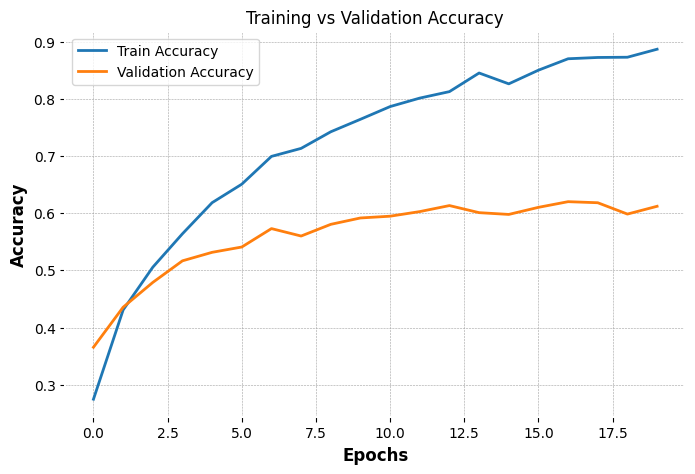

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

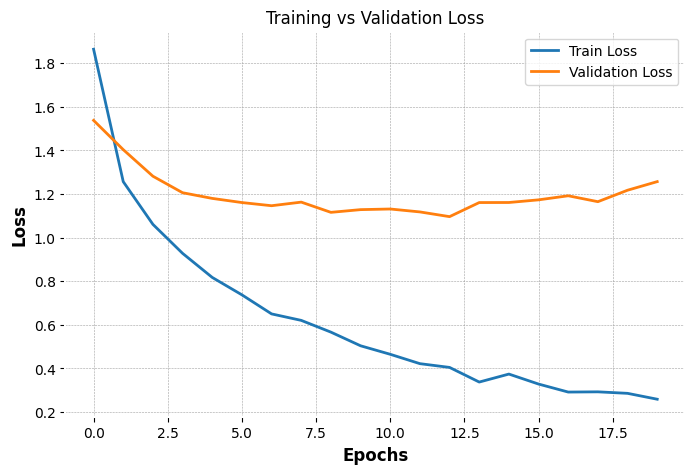

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()



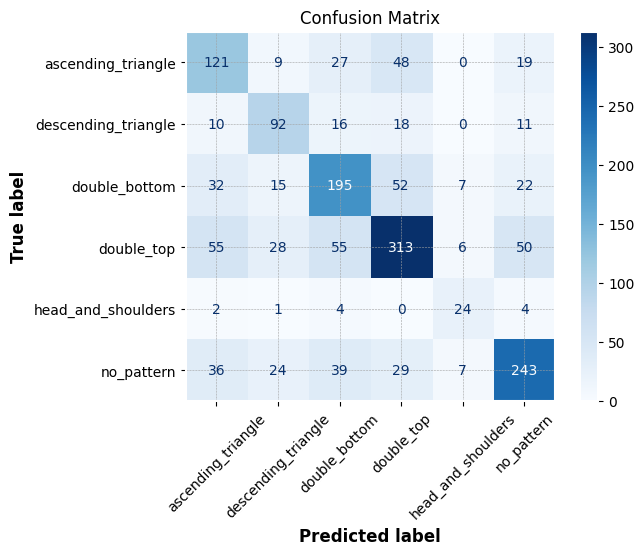

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [65]:
!ls

sample_data  stock-pattern-cnn	stock-pattern-recognition.zip


In [59]:
!zip -r stock-pattern-recognition.zip /content/stock-pattern-cnn

Streaming output truncated to the last 5000 lines.
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/MARUTI.NS_286.png (deflated 24%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/MARUTI.NS_276.png (deflated 24%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/HDFCBANK.NS_980.png (deflated 20%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/INFY.NS_668.png (deflated 22%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/INFY.NS_861.png (deflated 25%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/SBIN.NS_392.png (deflated 25%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/HDFCBANK.NS_960.png (deflated 21%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/HDFCBANK.NS_987.png (deflated 21%)
updating: content/stock-pattern-cnn/data/images/train/head_and_shoulders/INFY.NS_688.png (deflated 22